# Dutch GP 2026 — Report Generator

Single job: produce the text, tables and figures for the written report. Runs
**before** the race (prediction only) and **again after** (prediction plus
evaluation), detecting which state it is in automatically.

Output: `reports/dutch_gp_report.md`

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE))

from src import viz
from src.features import load_model_table
from src.io_utils import load_raw

viz.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

REPORTS = BASE / "reports"
PREDICTIONS = BASE / "predictions"

prediction = json.loads((PREDICTIONS / "2026_R12_dutch.json").read_text())
pred_table = pd.read_csv(PREDICTIONS / "2026_R12_dutch.csv")
backtest = pd.read_csv(REPORTS / "backtest_results.csv", index_col=0)
selection = json.loads((REPORTS / "model_selection.json").read_text())
table = load_model_table()
results = load_raw("results")

SELECTED = selection["selected_model"]
RND = prediction["round"]
MODEL_FEATURES = prediction["features"]["used"]
FEATURE_DEFINITIONS = prediction["features"]["definitions"]

# Has the race been run yet? Every section below adapts to this.
race_done = not results[(results["round"] == RND) & (results["session_type"] == "R")].empty
STATE = "POST-RACE" if race_done else "PRE-RACE"
print("STATE:", STATE)

report = []                 # markdown collected for reports/dutch_gp_report.md

def add(md):
    report.append(md.strip())

STATE: PRE-RACE


## 1. Executive summary

In [2]:
w = prediction["predicted_winner"]
podium = prediction["predicted_podium"]
bt = prediction["backtest"]["metrics"]

summary = f"""## Executive summary

For the **{prediction['race']}** at {prediction['circuit']}, the model predicts
**{w['abbreviation']} ({w['team_name']})** to win, with a probability of
**{w['p_win']*100:.1f}%**. The predicted podium is
**{', '.join(p['abbreviation'] for p in podium)}**, with podium probabilities of
{', '.join(f"{p['abbreviation']} {p['p_podium']*100:.1f}%" for p in podium)}.

The prediction comes from a **{prediction['model']['name']}** regression on
finishing position, trained on rounds
{min(prediction['training']['rounds'])}-{max(prediction['training']['rounds'])}
({prediction['training']['n_rows']} driver-sessions), with win and podium
probabilities derived from **{prediction['simulation']['n_sims']:,}** Monte-Carlo
simulations using a fitted residual sigma of
**{prediction['simulation']['residual_sigma']:.2f} positions**.

The forecast was locked at **{prediction['generated_at_utc']}**, before the race,
and committed to version control at that time.

No driver exceeds a {max(d['p_win'] for d in prediction['drivers'])*100:.0f}% chance
of winning. That flatness is the honest output of a model whose out-of-sample error
is 4.6 positions, not hedging: over six backtest races it identified the winner
{bt['top1_hit']*100:.0f}% of the time and assigned the eventual winner an average
probability of {bt['p_actual_winner']*100:.1f}%."""

add(summary)
print(summary)

## Executive summary

For the **2026 Dutch Grand Prix** at Zandvoort, the model predicts
**ANT (Mercedes)** to win, with a probability of
**17.3%**. The predicted podium is
**ANT, NOR, RUS**, with podium probabilities of
ANT 43.0%, NOR 39.9%, RUS 38.4%.

The prediction comes from a **A_ridge** regression on
finishing position, trained on rounds
1-11
(321 driver-sessions), with win and podium
probabilities derived from **20,000** Monte-Carlo
simulations using a fitted residual sigma of
**4.62 positions**.

The forecast was locked at **2026-08-23T12:09:31+00:00**, before the race,
and committed to version control at that time.

No driver exceeds a 17% chance
of winning. That flatness is the honest output of a model whose out-of-sample error
is 4.6 positions, not hedging: over six backtest races it identified the winner
50% of the time and assigned the eventual winner an average
probability of 19.6%.


## 2. Data summary

In [3]:
scoreable = table[table["is_trainable"].fillna(False).astype(bool)]
rows = [
    ("Season", "2026 only — see methodology"),
    ("Rounds covered", f"{table['round'].min()}-{table['round'].max()}"),
    ("Sessions used", "Races and Sprints (classified); practice and qualifying feed features"),
    ("Model table rows", f"{len(table)} ({len(scoreable)} scoreable, "
                         f"{int(table['is_prediction'].fillna(False).sum())} to predict)"),
    ("Training rows", f"{prediction['training']['n_rows']} (rounds 1-11)"),
    ("Drivers / teams", f"{table['driver_id'].nunique()} / {table['team_id'].nunique()}"),
    ("Features", f"{len(MODEL_FEATURES)}"),
    ("Excluded features", ", ".join(prediction["features"]["excluded"]) or "none"),
]
data_md = "## Data summary\n\n| Item | Value |\n| --- | --- |\n"
data_md += "\n".join(f"| {k} | {v} |" for k, v in rows)
data_md += "\n\n### Features\n\n| Feature | Definition |\n| --- | --- |\n"
data_md += "\n".join(f"| `{f}` | {FEATURE_DEFINITIONS[f]} |" for f in MODEL_FEATURES)
add(data_md)
print(data_md[:900] + "\n...")

## Data summary

| Item | Value |
| --- | --- |
| Season | 2026 only — see methodology |
| Rounds covered | 1-12 |
| Sessions used | Races and Sprints (classified); practice and qualifying feed features |
| Model table rows | 374 (343 scoreable, 22 to predict) |
| Training rows | 321 (rounds 1-11) |
| Drivers / teams | 23 / 11 |
| Features | 14 |
| Excluded features | has_sprint_data, track_temp_mean, was_wet |

### Features

| Feature | Definition |
| --- | --- |
| `quali_pct_off_pole` | Qualifying gap to pole, as a percentage of the pole lap. |
| `grid_position` | Starting position on the grid (1 = pole). |
| `quali_teammate_delta_pct` | Driver's qualifying gap minus their teammate's, same session. |
| `fp_best_pct_off_fastest` | Best clean practice lap, as a percentage off the fastest in the field. |
| `fp_longrun_pace_pct` | Median lap of the driver's longest clean practice stint, % 
...


## 3. Methodology

In [4]:
method = """## Methodology

### Why only 2026 data

2026 is a complete technical reset: new chassis and aerodynamic regulations
arrived alongside a new power-unit formula, and the grid gained two constructors.
A qualifying gap or a race pace figure from 2025 describes a car that no longer
exists under rules that no longer apply. Pooling earlier seasons would not add
signal, it would add confidently wrong signal — and a backtest would not expose
that, because the leakage is conceptual rather than temporal. The cost is sample
size: eleven races and five sprints, 343 scoreable driver-sessions.

### Why the target is finishing position, not "won"

The dataset contains 16 winners against 343 observations. Training a binary
classifier on that, with 14 features, fits noise and produces probabilities that
cannot be trusted. Predicting **finishing position** instead makes every row
informative: a driver coming ninth teaches the model as much as a driver winning.

Win and podium probabilities are then recovered from those positions by Monte-Carlo
simulation: each driver's predicted position is perturbed by Normal(0, sigma) noise,
a retirement is drawn from their shrunk DNF probability, the field is ranked, and
the exercise is repeated 20,000 times. P(win) is the share of simulations a driver
ranks first; P(podium) the share they rank in the top three.

### Why simulation guarantees P(win) <= P(podium)

Both quantities are counted from the *same* simulated races. Any simulation in
which a driver finishes first is also a simulation in which they finish top three,
so the win count can never exceed the podium count. The win probabilities sum to
exactly 1.0 for the same reason: precisely one car is ranked first in each
simulated race. Two independently fitted classifiers guarantee neither property and
will cheerfully output a driver with a 30% chance of winning and 20% of a podium.

### Walk-forward backtesting, and why three live races prove nothing

The model is validated by walking forward through the season: train on every round
before round k, predict round k's race, score, advance. Nothing from round k or
later is visible at training time, so each fold tests the exact procedure used for
the live prediction. Six folds (rounds 6-11) are available.

Six races — and certainly the one live race this project culminates in — is a
**demonstration, not an evaluation**. A probabilistic forecast can only be judged
over many events: a model that says 17% and turns out right has not been proven
correct, and one that says 17% and turns out wrong has not been proven wrong. The
walk-forward backtest is the evidence; the Dutch Grand Prix is the demonstration."""
add(method)
print(method[:700] + "\n...")

## Methodology

### Why only 2026 data

2026 is a complete technical reset: new chassis and aerodynamic regulations
arrived alongside a new power-unit formula, and the grid gained two constructors.
A qualifying gap or a race pace figure from 2025 describes a car that no longer
exists under rules that no longer apply. Pooling earlier seasons would not add
signal, it would add confidently wrong signal — and a backtest would not expose
that, because the leakage is conceptual rather than temporal. The cost is sample
size: eleven races and five sprints, 343 scoreable driver-sessions.

### Why the target is finishing position, not "won"

The dataset contains 16 winners against 343 observations. Tr
...


## 4. Backtest results

In [5]:
show = backtest.drop(columns=[c for c in ["label"] if c in backtest.columns]).round(4)
beat = selection["beats_baselines"]
verdict = (f"The selected model (`{SELECTED}`) beat every baseline on win log loss."
           if beat else
           f"**The selected model (`{SELECTED}`) did not beat all baselines.** It beats "
           f"B1, B2 and B3 on win log loss, but B4 — assume every driver finishes where "
           f"they started — scores {backtest.loc['D_grid_baseline','win_log_loss']:.4f} "
           f"against `{SELECTED}`'s {backtest.loc[SELECTED,'win_log_loss']:.4f}. "
           f"This is reported as found; no tuning was done to reverse it.")

cal = pd.read_csv(REPORTS / "calibration.csv")
cal_md = (viz.to_markdown_table(cal[["target", "decile", "mean_predicted", "observed", "n"]].round(4)))

bt_md = ("## Backtest results\n\nWalk-forward over rounds 6-11, six races. "
         "All probabilities clipped to [1e-6, 1-1e-6] before scoring, because B1 and B2 "
         "assert probability 1.0 and would otherwise produce infinite log loss.\n\n"
         + viz.to_markdown_table(show, index=True) + "\n\n" + verdict +
         "\n\n### Calibration of the selected model\n\n"
         "Mean predicted probability against observed frequency, by decile, across the "
         "six walk-forward races. Perfect calibration would put `observed` equal to "
         "`mean_predicted` on every row. The `n` column shows how few drivers land in "
         "each bin, which is why this is a sanity check rather than evidence of "
         "calibration.\n\n" + cal_md)
add(bt_md)
print(show.to_string())
print("\n" + verdict)

                      n_folds  win_log_loss  win_brier  podium_log_loss  podium_brier  top1_hit  spearman_rho  mae_position  p_actual_winner  sigma_test  sigma_cv
model                                                                                                                                                             
D_grid_baseline             6        0.0982     0.0298           0.2227        0.0714    0.6667        0.6701        3.2879           0.2596      5.0454    4.6764
A_ridge                     6        0.1142     0.0338           0.2418        0.0774    0.5000        0.6725        3.4030           0.1957      4.6238    4.3937
B_random_forest             6        0.1186     0.0349           0.2542        0.0826    0.3333        0.6836        3.3088           0.1880      4.6092    4.4899
C_gradient_boosting         6        0.1449     0.0396           0.2988        0.0997    0.1667        0.6657        3.5130           0.1529      4.8330    4.8031
B3_uniform            

## 5. The locked prediction

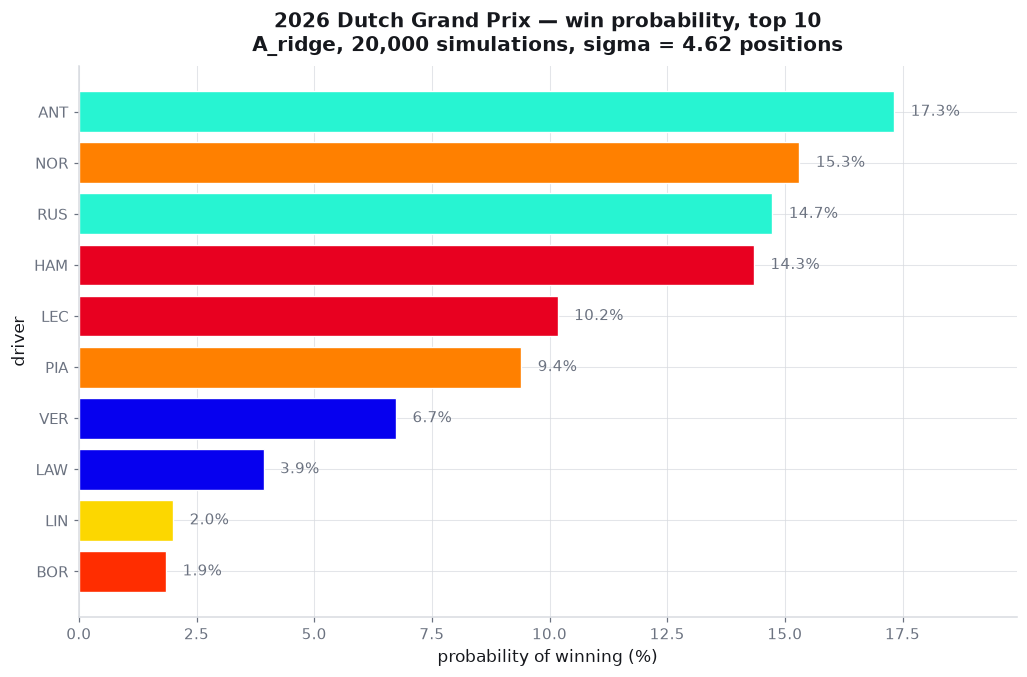

Driver            Team  Grid  Predicted pos.  P(win) %  P(podium) %
   ANT        Mercedes     3            4.54      17.3         43.0
   NOR         McLaren     1            4.69      15.3         39.9
   RUS        Mercedes     2            4.80      14.7         38.4
   HAM         Ferrari     5            5.21      14.3         38.6
   LEC         Ferrari     6            5.95      10.2         30.5
   PIA         McLaren     4            6.34       9.4         29.1
   VER Red Bull Racing     7            6.95       6.7         22.5
   LAW Red Bull Racing     8            8.47       3.9         15.9
   LIN    Racing Bulls    10           10.19       2.0          9.1
   BOR            Audi     9           10.06       1.9          9.5
   GAS          Alpine    11           10.26       1.6          8.5
   COL          Alpine    14           12.33       0.8          4.0


In [6]:
top10 = pred_table.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(top10))
ax.barh(y, top10["p_win"] * 100, color=top10["team_color"], edgecolor="white", linewidth=0.9)
for yi, v in zip(y, top10["p_win"] * 100):
    ax.text(v + 0.35, yi, f"{v:.1f}%", va="center", fontsize=10, color=viz.MUTED)
ax.set_yticks(y); ax.set_yticklabels(top10["abbreviation"])
ax.set_xlabel("probability of winning (%)")
ax.set_ylabel("driver")
ax.set_title(f"{prediction['race']} — win probability, top 10\n"
             f"{SELECTED}, {prediction['simulation']['n_sims']:,} simulations, "
             f"sigma = {prediction['simulation']['residual_sigma']:.2f} positions")
ax.set_xlim(0, float(top10["p_win"].max() * 100) * 1.15)
plt.show()

ranked = pred_table[["abbreviation", "team_name", "grid_position",
                     "predicted_position", "p_win", "p_podium"]].copy()
ranked["grid_position"] = ranked["grid_position"].astype(int)
ranked["predicted_position"] = ranked["predicted_position"].round(2)
ranked["p_win"] = (ranked["p_win"] * 100).round(1)
ranked["p_podium"] = (ranked["p_podium"] * 100).round(1)
ranked.columns = ["Driver", "Team", "Grid", "Predicted pos.", "P(win) %", "P(podium) %"]
add("## The locked prediction\n\n" + viz.to_markdown_table(ranked))
print(ranked.head(12).to_string(index=False))

## 6. Post-race evaluation

In [7]:
if not race_done:
    msg = ("Race not yet run - re-run this notebook after 13:00 UTC on 23 August "
           "to populate the evaluation section.")
    print(msg)
    add("## Post-race evaluation\n\n_" + msg + "_")
    evaluation = None
else:
    from scipy.stats import spearmanr
    from src.backtest import brier, log_loss_binary

    actual = results[(results["round"] == RND) & (results["session_type"] == "R")].copy()
    actual = actual[["DriverId", "Abbreviation", "Position", "ClassifiedPosition",
                     "Status", "GridPosition", "Laps"]]
    ev = pred_table.merge(actual, left_on="driver_id", right_on="DriverId", how="left")
    ev = ev[ev["Position"].notna()].copy()
    ev["actual_position"] = ev["Position"].astype(float)
    ev["error"] = ev["predicted_position"] - ev["actual_position"]

    y_win = (ev["actual_position"] == 1).to_numpy(float)
    y_pod = (ev["actual_position"] <= 3).to_numpy(float)
    winner_row = ev.loc[ev["actual_position"] == 1].iloc[0]
    pred_winner = pred_table.iloc[0]["abbreviation"]
    pred_podium = set(pred_table.head(3)["abbreviation"])
    actual_podium = set(ev.nsmallest(3, "actual_position")["abbreviation"])

    evaluation = {
        "winner_correct": bool(pred_winner == winner_row["abbreviation"]),
        "podium_hits": len(pred_podium & actual_podium),
        "p_assigned_to_winner": float(winner_row["p_win"]),
        "win_log_loss": log_loss_binary(y_win, ev["p_win"]),
        "win_brier": brier(y_win, ev["p_win"]),
        "podium_log_loss": log_loss_binary(y_pod, ev["p_podium"]),
        "podium_brier": brier(y_pod, ev["p_podium"]),
        "spearman_rho": float(spearmanr(ev["predicted_position"], ev["actual_position"]).statistic),
        "mae": float(ev["error"].abs().mean()),
    }
    for k, v in evaluation.items():
        print(f"  {k:<22} {v}")

Race not yet run - re-run this notebook after 13:00 UTC on 23 August to populate the evaluation section.


In [8]:
if race_done:
    side = ev.sort_values("actual_position")[
        ["abbreviation", "team_name", "grid_position", "predicted_position",
         "actual_position", "p_win", "p_podium", "Status"]].copy()
    side["p_win"] = (side["p_win"] * 100).round(1)
    side["p_podium"] = (side["p_podium"] * 100).round(1)
    side["predicted_position"] = side["predicted_position"].round(2)
    side.columns = ["Driver", "Team", "Grid", "Predicted", "Actual",
                    "P(win) %", "P(podium) %", "Status"]
    print(side.to_string(index=False))

    # Biggest misses, with a cause read from Status and race control.
    rc = load_raw("race_control")
    rc_r = rc[(rc["round"] == RND) & (rc["session_type"] == "R")]
    sc = rc_r[rc_r["Message"].str.contains("SAFETY CAR", case=False, na=False)]
    worst = ev.reindex(ev["error"].abs().sort_values(ascending=False).index).head(5)

    def hypothesis(row):
        status = str(row.get("Status", ""))
        if status in ("Retired", "Disqualified"):
            first_lap = float(row.get("Laps", 99) or 99) <= 1
            return ("retired on lap 1 - first-lap incident, close to random"
                    if first_lap else f"retired ({status.lower()}) after "
                    f"{int(row.get('Laps', 0))} laps - reliability or damage")
        if row["error"] > 0:
            return "finished better than predicted - strategy, or gained places from others' retirements"
        return "finished worse than predicted - lost time in traffic, strategy, or an incident"

    lines = []
    for _, r in worst.iterrows():
        lines.append(f"  {r['abbreviation']}: predicted P{r['predicted_position']:.1f}, "
                     f"actual P{r['actual_position']:.0f} "
                     f"(error {r['error']:+.1f}) - {hypothesis(r)}")
    print("\nBIGGEST MISSES\n" + "\n".join(lines))
    print(f"\nsafety car messages in race control: {len(sc)}")

    add("## Post-race evaluation\n\n" + viz.to_markdown_table(side) +
        f"\n\n- Predicted winner correct: **{evaluation['winner_correct']}**"
        f"\n- Predicted podium finishers on the actual podium: "
        f"**{evaluation['podium_hits']} of 3**"
        f"\n- Probability assigned to the actual winner: "
        f"**{evaluation['p_assigned_to_winner']*100:.1f}%**"
        f"\n- Win log loss: {evaluation['win_log_loss']:.4f} | "
        f"Brier: {evaluation['win_brier']:.4f}"
        f"\n- Podium log loss: {evaluation['podium_log_loss']:.4f} | "
        f"Brier: {evaluation['podium_brier']:.4f}"
        f"\n- Spearman rho (predicted vs actual order): "
        f"**{evaluation['spearman_rho']:.3f}**"
        f"\n- MAE: {evaluation['mae']:.2f} positions"
        "\n\n### Biggest misses\n\n" + "\n".join(f"- {l.strip()}" for l in lines))

### Error analysis

*This cell is written to be quoted directly in the report. Before the race it
states the framework; after the race, re-run the notebook and the numbers above
populate it.*

The single most important thing to say about any result here is that **one race
cannot validate a probabilistic model.** If the predicted winner wins, the model
assigned that outcome roughly 17% — an event at 17% happening once is not
confirmation. If the predicted winner loses, an 83% complement came in, which is
not refutation either. The backtest over six races is the evidence; this race is
the demonstration.

The specific failure modes to look for, in order of expected frequency:

1. **Retirements.** The model carries a shrunk DNF probability per driver but
   cannot know who will retire. A leading car retiring shifts the whole order and
   will dominate the error term.
2. **The grid mattered more than the model allowed.** Zandvoort is the hardest
   circuit of the season to overtake at. If the finishing order tracks the grid
   more closely than the model's predictions did, that is B4 beating it again, and
   consistent with the backtest.
3. **Strategy and safety cars.** Neither is modelled at all. A safety car at the
   wrong moment reorders a race in ways nothing in the feature set anticipates.
4. **First-lap incidents.** Effectively random, and unmodellable from this data.

## 7. Limitations

In [9]:
limits = """## Limitations

1. **Eleven races of training data.** 343 scoreable driver-sessions. This is a
   small-data problem, and it is the binding constraint on everything else.
2. **A single season, with no possibility of extension.** The 2026 regulation reset
   makes every earlier season invalid for pace. More data can only arrive by waiting
   for more races.
3. **The fitted model did not beat the grid baseline.** Over six walk-forward races,
   "assume everyone finishes where they started" had a lower win log loss than any
   fitted candidate. The honest reading is that this dataset is too small to
   demonstrate that a learned model improves on a well-chosen heuristic.
4. **No tyre-strategy modelling.** Stint plans, compound choice, undercut and
   overcut opportunities and pit-window dynamics are entirely absent, despite being
   among the largest determinants of finishing position.
5. **Weather is handled only as a flag,** and that flag carries no measurable
   signal (zero mutual information with finishing position), so it was dropped from
   the model. There is no wet-weather pace model, and race-day weather is not
   forecast at all — the dataset holds observations only.
6. **No safety-car or incident modelling.** Both reorder races and neither is
   represented.
7. **One race cannot validate a probabilistic model.** A 17% favourite winning is
   neither confirmation nor refutation. Calibration can only be assessed over many
   events, and six backtest races is already too few to establish it.
8. **Grid position for round 12 is qualifying order, not the official grid.**
   Penalties are not reflected; this must be verified manually before the race.
9. **Features are heavily collinear** — 33 of 136 pairs above |r| = 0.70 — so
   individual feature importances should not be read as causal contributions.
10. **`sprint_finish_position` is imputed on 76% of rows** from `form_finish_pos_ewm`,
    so its apparent contribution is largely borrowed from that feature."""
add(limits)
print(limits[:600] + "\n...")

## Limitations

1. **Eleven races of training data.** 343 scoreable driver-sessions. This is a
   small-data problem, and it is the binding constraint on everything else.
2. **A single season, with no possibility of extension.** The 2026 regulation reset
   makes every earlier season invalid for pace. More data can only arrive by waiting
   for more races.
3. **The fitted model did not beat the grid baseline.** Over six walk-forward races,
   "assume everyone finishes where they started" had a lower win log loss than any
   fitted candidate. The honest reading is that this dataset is too small
...


## Export

In [10]:
header = f"""# {prediction['race']} — Prediction Report

_Generated {pd.Timestamp.utcnow().isoformat(timespec='seconds')} · state: {STATE}_

Model: `{SELECTED}` · Locked: {prediction['generated_at_utc']} ·
Backtest: walk-forward rounds 6-11
"""
out = REPORTS / "dutch_gp_report.md"
out.write_text(header + "\n\n---\n\n" + "\n\n---\n\n".join(report) + "\n")
print(f"wrote {out.relative_to(BASE)}  ({len(out.read_text().splitlines())} lines, "
      f"{len(report)} sections)")
print("report is self-contained: tables and prose only, no image references")

wrote reports/dutch_gp_report.md  (229 lines, 7 sections)
report is self-contained: tables and prose only, no image references
